# rabi_experiment_prototype_sh

### Prototype pulse sequence for the rabi oscillation experiment, utilizing the sequence_helper library

Connect:
- QCM out 0 to oscilloscope
- QCM out 1 to oscillocsope
- RF out 0 to oscolloscope
- QRM out 1 to QRM in 1

Authors: Kyle MacRobbie, Ben Van Osch

---

## Expeiment sequence summary

|Step|Physical Description|Gate 1|Gate 2|QCM-RF output|
|-|-|-|-|-|
|1|Load electron into (1,0) state|Constant at -0.325 V|Constant at -0.25 V|None|
|2|Load electron into (2,0)S state|Constant at -0.395 V|Constant at -0.25 V|None|
|3|Tunnel electron into (1,1)S state|Ramp from -0.395 V to -0.325 V|Ramp from -0.25 V to -0.325 V|None|
|4|Apply RF pulse|Constant at -0.325 V|Constant at -0.325 V|RF pulse|
|5|Readout|Ramp from -0.325 V to -0.38 V and wait|Ramp from -0.325 V to -0.27 V and wait|None|
|6|Unload electrons|Ramp from -0.38 V to -0.325 V|Ramp from -0.27 V to -0.25 V|None|

<br>

---

### Setup

In [8]:
# Imports
import matplotlib.pyplot as plt
import pyvisa
import numpy as np
from __future__ import annotations 
from typing import TYPE_CHECKING, Callable
from qcodes.instrument import find_or_create_instrument
from qblox_instruments import Cluster, ClusterType
if TYPE_CHECKING:
    from qblox_instruments.qcodes_drivers.module import Module
import sys
sys.path.append(r"C:\\Users\\BaughLaflamme\\Desktop\\Qblox Master Folder\\Cluster\\Libraries\\Qblox Sequence Helper")
import sequence_helper as sh

In [9]:
cluster_ip = "192.168.137.2"
cluster_name = "cluster0"
cluster = find_or_create_instrument(
    Cluster,
    recreate=True,
    name=cluster_name,
    identifier=cluster_ip,
    dummy_cfg=(
        {
            2: ClusterType.CLUSTER_QCM,
            4: ClusterType.CLUSTER_QRM,
            6: ClusterType.CLUSTER_QCM_RF,
        }
        if cluster_ip is None
        else None
    ),
)
cluster.led_brightness('medium') # Sets LED brightness on the modules. Options are 'low', 'medium' and 'high'
# Get modules, and connect to the QRM
def get_connected_modules(cluster: Cluster, filter_fn: Callable | None = None) -> dict[int, Module]:
    def checked_filter_fn(mod: ClusterType) -> bool:
        if filter_fn is not None:
            return filter_fn(mod)
        return True
    return {
        mod.slot_idx: mod for mod in cluster.modules if mod.present() and checked_filter_fn(mod)
    }
modules = get_connected_modules(cluster)
module = list(modules.values())[0]
cluster.reset()
print(cluster.get_system_status())
qrm_module = modules[4]
qcm_module = modules[2]
rf_module = modules[6]
rm = pyvisa.ResourceManager()
scope = rm.open_resource('GPIB0::8::INSTR')

Status: OKAY, Flags: NONE, Slot flags: NONE


In [3]:
# Setting the oscilloscope ranges
scope.write(f'TIME_DIV {5000e-9} S')	# Set the time scale on all oscilloscope channels
scope.write(f'C1:VOLT_DIV {0.05} V')	# Set the voltage scale on channel 1
scope.write(f'C2:VOLT_DIV {0.05} V')	# Set the voltage scale on channel 2
scope.write(f'C3:VOLT_DIV {0.5} V')	    # Set the voltage scale on channel 2
scope.write(f'C4:VOLT_DIV {1.5} V')	    # Set the voltage scale on channel 2
scope.write(f'TRIG_DELAY {0}')			# Set the time scale left/right on the display
scope.write(f'TRIG_MODE NORMAL')		# Set the trigger mode to "single" in order to take one acquisition

18

---

### Sequence

In [4]:
# Set up gate voltages for different steps
offs11 = 0		# V	# Offset for gate 1 step 1
offs12 = 0.07	# V	# Offset for gate 1 step 2
offs13 = 0		# V	# Offset for gate 1 step 3
offs14 = 0.055	# V	# Offset for gate 1 step 4

offs21 = 0		# V	# Offset for gate 1 step 1
offs22 = 0		# V	# Offset for gate 1 step 2
offs23 = 0.075	# V	# Offset for gate 1 step 3
offs24 = 0.02	# V	# Offset for gate 1 step 4

rf_magnitude = 0.5	# Magnitude of the RF pulse

# Set up pulse times
ramp_length = 200 		 # ns
gate_pulse_length = 5000 # ns
readout_length = 10000 	 # ns
rf_pulse_length = 10000  # ns

In [5]:
# Define steps
steps_out0 = [
	['square', gate_pulse_length, offs11],
	['ramp', ramp_length, offs11, offs12],
	['square', gate_pulse_length, offs12],
	['ramp', ramp_length, offs12, offs13],
	['square', rf_pulse_length, offs13],
	['ramp', ramp_length, offs13, offs14],
	['square', readout_length, offs14],
	['ramp', ramp_length, offs14, offs11]
]
steps_out1 = [
	['square', gate_pulse_length, offs21],
	['ramp', ramp_length, offs21, offs22],
	['square', gate_pulse_length, offs22],
	['ramp', ramp_length, offs22, offs23],
	['square', rf_pulse_length, offs23],
	['ramp', ramp_length, offs23, offs24],
	['square', readout_length, offs24],
	['ramp', ramp_length, offs24, offs21]
]
steps_rf = [
	['wait', (ramp_length * 2) + (gate_pulse_length * 2)],
	['square', rf_pulse_length, rf_magnitude],
	['wait', (ramp_length * 2) + readout_length]
]
steps_in = ['acq', (ramp_length * 3) + (gate_pulse_length * 2) + rf_pulse_length, readout_length]

# I will also define a simulated readout pulse to be played from the QRM and read by the QRM
steps_out_sim = [
	['square', (ramp_length * 3) + (gate_pulse_length * 2) + rf_pulse_length + (readout_length / 4), 0],
	['square', (readout_length * 0.5), 0.03],
	['square', 100, 0]
]

# Set number of Q1ASM loops
num_loops = 1000

# Disconnect all outputs
sh.disconnect_io(qcm_module)
sh.disconnect_io(rf_module)
sh.disconnect_io(qrm_module)

# Upload sequences to their respective sequencers
qcm_module.sequencer0.sequence(sh.make_output_sequence(input = steps_out0, module = 'qcm', iterations = num_loops))
qcm_module.sequencer1.sequence(sh.make_output_sequence(input = steps_out1, module = 'qcm', iterations = num_loops))
rf_module.sequencer0.sequence(sh.make_rf_sequence(input = steps_rf, marker = 0, iterations = num_loops))
qrm_module.sequencer0.sequence(sh.make_input_sequence(input = steps_in, iterations = num_loops, resolution = 300))
qrm_module.sequencer1.sequence(sh.make_output_sequence(input = steps_out_sim, module = 'qrm', iterations = num_loops))

# Connect outputs
sh.connect_output(module = qcm_module, sequencer = 0, output_index = 0, path = 0)
sh.connect_output(module = qcm_module, sequencer = 1, output_index = 1, path = 0)
sh.connect_rf_output(module = rf_module, sequencer = 0, output_index = 0, nco_freq = 50e6, lo_freq = 2e9)
sh.connect_input(module = qrm_module, sequencer = 0, input_index = 0, path = 0, resolution = 300)
sh.connect_output(module = qrm_module, sequencer = 1, output_index = 0, path = 0)

# Correcting input offset
qrm_module.in0_offset(-0.006)
qrm_module.in1_offset(-0.001)

# Arm sequencers
qcm_module.arm_sequencer(0)
qcm_module.arm_sequencer(1)
rf_module.arm_sequencer(0)
qrm_module.arm_sequencer(0)
qrm_module.arm_sequencer(1)

# Start sequencer
cluster.start_sequencer()

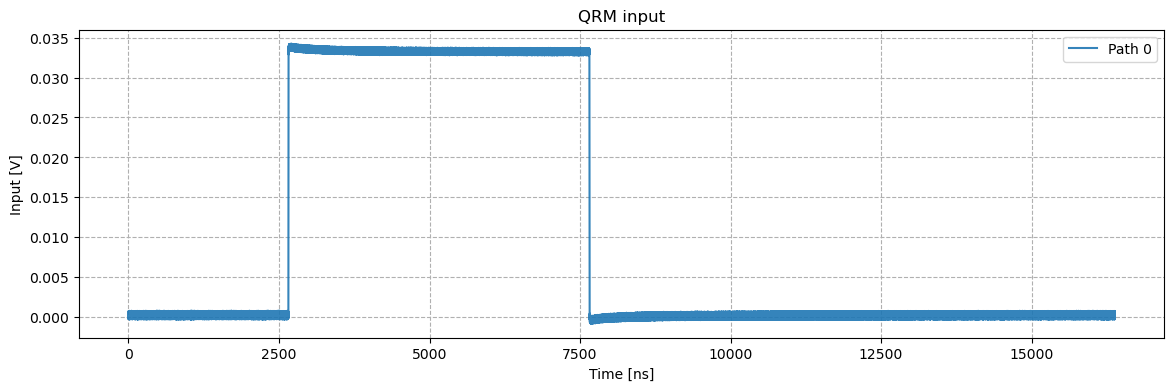

In [6]:
# Plotting
sh.plot_input(module = qrm_module, sequencer = 0, acquisition_name = 'acq', path = 0, range = [0, 10000000000000])

---

### Stopping

In [10]:
# Stop and check status
cluster.stop_sequencer()
print("QCM sequencer 0:  " + str(qcm_module.get_sequencer_status(0)))
print("QCM sequencer 1:  " + str(qcm_module.get_sequencer_status(1)))
print("RF sequencer 1:   " + str(rf_module.get_sequencer_status(0)))
print("QRM sequencer 1:  " + str(qrm_module.get_sequencer_status(0)))
print("QRM sequencer 1:  " + str(qrm_module.get_sequencer_status(1)))
cluster.reset()
print(cluster.get_system_status())

QCM sequencer 0:  Status: OKAY, State: STOPPED, Info Flags: NONE, Warning Flags: NONE, Error Flags: NONE, Log: []
QCM sequencer 1:  Status: OKAY, State: STOPPED, Info Flags: NONE, Warning Flags: NONE, Error Flags: NONE, Log: []
RF sequencer 1:   Status: OKAY, State: STOPPED, Info Flags: NONE, Warning Flags: NONE, Error Flags: NONE, Log: []
QRM sequencer 1:  Status: OKAY, State: STOPPED, Info Flags: FORCED_STOP, Warning Flags: NONE, Error Flags: NONE, Log: []
QRM sequencer 1:  Status: OKAY, State: STOPPED, Info Flags: FORCED_STOP, Warning Flags: NONE, Error Flags: NONE, Log: []
Status: OKAY, Flags: NONE, Slot flags: NONE
